# 02 - Returns, risk statistics and portfolio construction

**Goal:** turn raw prices into daily returns, measure the risk of each stock
(volatility, correlation), then build an equal-weighted portfolio and measure
its risk.

**Universe:** AAPL, MSFT, JPM, XOM, JNJ, AMZN, KO, WMT. **Benchmark:** S&P 500 (SPY).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'AMZN', 'KO', 'WMT']
BENCHMARK = 'SPY'
TRADING_DAYS = 252
RISK_FREE = 0.02

## 1. Load the data

Daily adjusted close prices were downloaded with `yfinance` in notebook 01 and
saved in `data/prices.csv` (from 2007 to today, to include the 2008 and 2020 crises).

In [2]:
prices = pd.read_csv('../data/prices.csv', index_col=0, parse_dates=True)
print(prices.shape)

(4973, 9)


## 2. Daily returns

Risk is measured on returns, not on prices, because returns are comparable
across assets of different price levels.

- **Simple return:** P_t / P_(t-1) - 1. Additive across assets, so used for portfolios and VaR.
- **Log return:** ln(P_t / P_(t-1)). Additive over time.

In [3]:
returns = prices.pct_change().dropna()                    # simple returns
log_returns = np.log(prices / prices.shift(1)).dropna()   # log returns

stocks = returns[TICKERS]      # the 8 stocks
market = returns[BENCHMARK]    # the S&P 500 (SPY)

print(returns.shape)
stocks.head()

(4972, 9)


,AAPL,MSFT,JPM,XOM,JNJ,AMZN,KO,WMT
Date,,,,,,,,
2007-01-04,0.022196,-0.001675,0.002496,-0.018757,0.012500,0.005168,0.000411,0.004837
2007-01-05,-0.007122,-0.005703,-0.008300,0.007151,-0.009073,-0.013625,-0.006995,-0.008162
2007-01-08,0.004939,0.009784,0.003348,-0.008056,-0.001651,-0.022674,0.006423,-0.008230
2007-01-09,0.083070,0.001003,-0.004171,-0.007708,-0.003759,0.007467,0.000823,0.008298
2007-01-10,0.047856,-0.010013,0.007329,-0.015259,-0.001660,-0.016676,0.001440,-0.002321


In [4]:
print((stocks.describe() * 100).round(2))

            AAPL       MSFT        JPM        XOM        JNJ       AMZN  \
count  497200.00  497200.00  497200.00  497200.00  497200.00  497200.00   
mean        0.12       0.08       0.08       0.04       0.04       0.13   
std         1.97       1.77       2.33       1.70       1.12       2.37   
min       -17.92     -14.74     -20.73     -13.95     -10.04     -14.05   
25%        -0.78      -0.76      -0.83      -0.77      -0.46      -1.00   
50%         0.11       0.06       0.06       0.03       0.03       0.07   
75%         1.11       0.94       0.95       0.86       0.59       1.24   
max        15.33      18.60      25.10      17.19      12.23      26.95   

              KO        WMT  
count  497200.00  497200.00  
mean        0.04       0.06  
std         1.18       1.32  
min        -9.67     -11.38  
25%        -0.51      -0.56  
50%         0.06       0.07  
75%         0.60       0.68  
max        13.88      11.71  


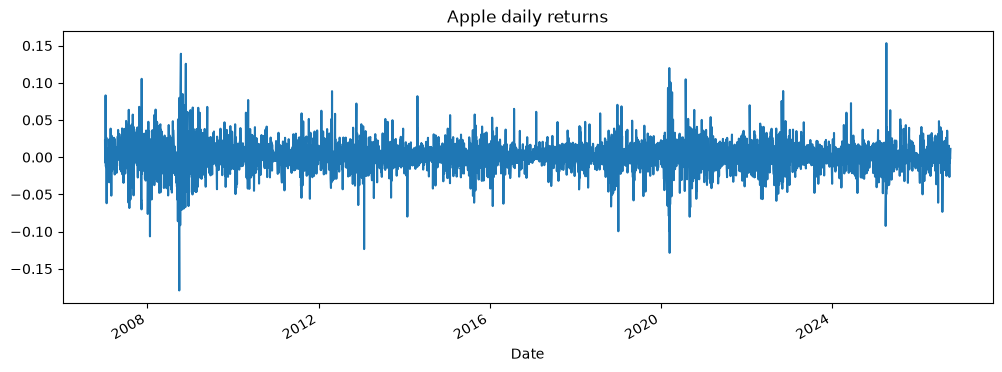

In [5]:
stocks['AAPL'].plot(figsize=(12, 4), title='Apple daily returns')
plt.show()

## 3. Volatility

Volatility is the standard deviation of returns: it measures how much returns
move around their average.

To annualize it, I multiply the daily volatility by sqrt(252), the number of
trading days in a year.

In [6]:
# Daily volatility = standard deviation of daily returns, one value per stock
vol_daily = stocks.std()
print((vol_daily * 100).round(2))

AAPL    1.97
MSFT    1.77
JPM     2.33
XOM     1.70
JNJ     1.12
AMZN    2.37
KO      1.18
WMT     1.32
dtype: float64


In [7]:
# Annualized volatility = daily volatility x square root of trading days
vol_annual = vol_daily * np.sqrt(TRADING_DAYS)
print((vol_annual * 100).round(1))

AAPL    31.2
MSFT    28.1
JPM     37.0
XOM     27.0
JNJ     17.7
AMZN    37.6
KO      18.7
WMT     21.0
dtype: float64


In [8]:
# Check: recompute AAPL daily volatility with the formula
r = stocks['AAPL']
manual_vol = np.sqrt(((r - r.mean()) ** 2).sum() / (len(r) - 1))
print(manual_vol, vol_daily['AAPL'])

0.019659357919720594 0.019659357919720594


In [9]:
# Benchmark volatility, for reference
market_vol = market.std() * np.sqrt(TRADING_DAYS)
print(f'S&P 500 annualized volatility: {market_vol:.1%}')

S&P 500 annualized volatility: 19.5%


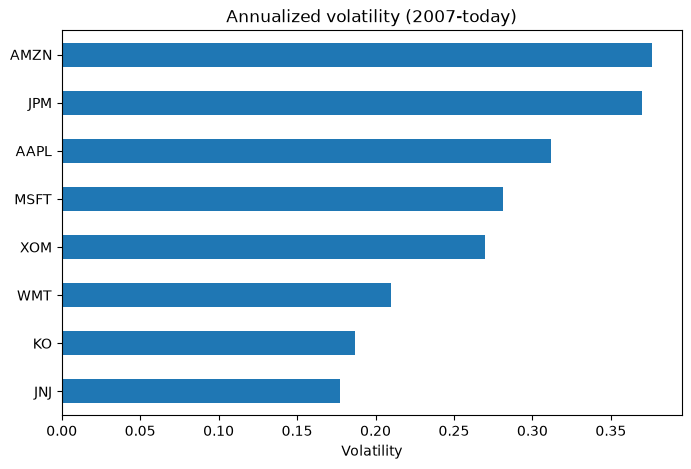

In [10]:
# Sort from lowest to highest volatility, then plot as horizontal bars
vol_annual = vol_annual.sort_values()
vol_annual.plot(kind='barh', figsize=(8, 5), title='Annualized volatility (2007-today)')
plt.xlabel('Volatility')
plt.show()

Amazon is the most volatile stock in the portfolio (37.6% per year), while Johnson & Johnson is the least volatile (17.7%).
Amazon is a growth company whose valuation depends heavily on future expectations, so it reacts strongly to market news.
Johnson & Johnson belongs to the healthcare sector, which is defensive: its demand is stable whatever the economic cycle.

## 4. Covariance and correlation

- **Covariance** measures whether two stocks move together (positive) or in opposite
  directions (negative). The diagonal of the covariance matrix contains the variances.
- **Correlation** = covariance / (vol A x vol B). It is unitless and always between -1 and +1.

For annualization, covariances are multiplied by 252, whereas correlations are not
annualized (they are ratios).

In [11]:
# Covariance matrix of daily returns (8 x 8)
cov_daily = stocks.cov()
print((cov_daily * 10000).round(2))   # x 10,000 only to make small numbers readable

      AAPL  MSFT   JPM   XOM   JNJ  AMZN    KO   WMT
AAPL  3.86  1.89  1.90  1.13  0.70  2.26  0.78  0.80
MSFT  1.89  3.14  1.80  1.14  0.73  2.29  0.83  0.78
JPM   1.90  1.80  5.42  1.86  0.96  1.97  1.03  0.93
XOM   1.13  1.14  1.86  2.89  0.79  1.09  0.87  0.65
JNJ   0.70  0.73  0.96  0.79  1.25  0.67  0.70  0.60
AMZN  2.26  2.29  1.97  1.09  0.67  5.62  0.69  0.82
KO    0.78  0.83  1.03  0.87  0.70  0.69  1.39  0.61
WMT   0.80  0.78  0.93  0.65  0.60  0.82  0.61  1.75


In [12]:
# The diagonal of the covariance matrix is the variance of each stock
print(np.allclose(np.diag(cov_daily), vol_daily ** 2))

True


In [13]:
# Annualized covariance: multiply by 252 (variances and covariances add up over time)
cov_annual = cov_daily * TRADING_DAYS
print(cov_annual.round(4))

        AAPL    MSFT     JPM     XOM     JNJ    AMZN      KO     WMT
AAPL  0.0974  0.0477  0.0478  0.0284  0.0176  0.0569  0.0195  0.0201
MSFT  0.0477  0.0792  0.0453  0.0287  0.0184  0.0578  0.0208  0.0197
JPM   0.0478  0.0453  0.1366  0.0468  0.0242  0.0497  0.0261  0.0234
XOM   0.0284  0.0287  0.0468  0.0728  0.0200  0.0276  0.0220  0.0165
JNJ   0.0176  0.0184  0.0242  0.0200  0.0314  0.0168  0.0176  0.0151
AMZN  0.0569  0.0578  0.0497  0.0276  0.0168  0.1416  0.0173  0.0207
KO    0.0195  0.0208  0.0261  0.0220  0.0176  0.0173  0.0350  0.0154
WMT   0.0201  0.0197  0.0234  0.0165  0.0151  0.0207  0.0154  0.0442


In [14]:
# Correlation matrix (8 x 8), values between -1 and +1
corr = stocks.corr()
print(corr.round(2))

      AAPL  MSFT   JPM   XOM   JNJ  AMZN    KO   WMT
AAPL  1.00  0.54  0.41  0.34  0.32  0.48  0.33  0.31
MSFT  0.54  1.00  0.44  0.38  0.37  0.55  0.40  0.33
JPM   0.41  0.44  1.00  0.47  0.37  0.36  0.38  0.30
XOM   0.34  0.38  0.47  1.00  0.42  0.27  0.44  0.29
JNJ   0.32  0.37  0.37  0.42  1.00  0.25  0.53  0.41
AMZN  0.48  0.55  0.36  0.27  0.25  1.00  0.25  0.26
KO    0.33  0.40  0.38  0.44  0.53  0.25  1.00  0.39
WMT   0.31  0.33  0.30  0.29  0.41  0.26  0.39  1.00


In [15]:
# corr(AAPL, MSFT) = cov(AAPL, MSFT) / (vol AAPL x vol MSFT)
manual_corr = cov_daily.loc['AAPL', 'MSFT'] / (vol_daily['AAPL'] * vol_daily['MSFT'])
print(manual_corr, corr.loc['AAPL', 'MSFT'])

0.5432430455284253 0.5432430455284251


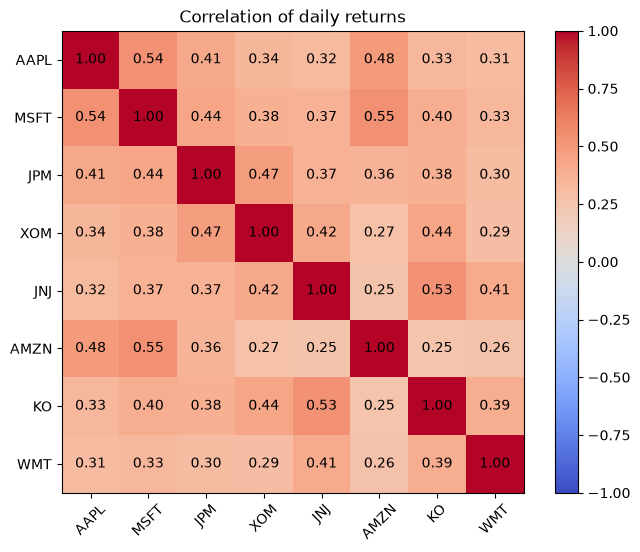

In [16]:
# Correlation heatmap with the value written in each cell
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

fig.colorbar(im)
ax.set_title('Correlation of daily returns')
plt.show()

In [17]:
def pairwise_corr(df):
    # Return the correlation of every pair of columns (each pair once), sorted
    c = df.corr()
    mask = np.triu(np.ones(c.shape), k=1).astype(bool)
    return c.where(mask).stack().dropna().sort_values()

pairs = pairwise_corr(stocks)
print('Number of pairs:', len(pairs))   # should be 28
print('Lowest correlations:')
print(pairs.head(3).round(2))
print('Highest correlations:')
print(pairs.tail(3).round(2))

Number of pairs: 28
Lowest correlations:
AMZN  KO      0.25
JNJ   AMZN    0.25
AMZN  WMT     0.26
dtype: float64
Highest correlations:
JNJ   KO      0.53
AAPL  MSFT    0.54
MSFT  AMZN    0.55
dtype: float64


In [18]:
# Average pairwise correlation: full period vs calm year vs Covid crash
avg_full = pairwise_corr(stocks).mean()
avg_calm = pairwise_corr(stocks.loc['2017-01-01':'2017-12-31']).mean()
avg_covid = pairwise_corr(stocks.loc['2020-02-19':'2020-03-23']).mean()

print(f'Full period: {avg_full:.2f}')
print(f'Calm year (2017): {avg_calm:.2f}')
print(f'Covid crash (Feb-Mar 2020): {avg_covid:.2f}')

Full period: 0.38
Calm year (2017): 0.12
Covid crash (Feb-Mar 2020): 0.79


## 5. Equal-weighted portfolio

The portfolio daily return is the weighted sum of the stock returns:
r_p = sum(w_i x r_i), with 12.5% in each stock.



In [19]:
# Equal-weighted portfolio: 1/8 = 12.5% in each stock
weights = pd.Series(1 / len(TICKERS), index=TICKERS)
print(weights)
print('Sum of weights:', weights.sum())

AAPL    0.125
MSFT    0.125
JPM     0.125
XOM     0.125
JNJ     0.125
AMZN    0.125
KO      0.125
WMT     0.125
dtype: float64
Sum of weights: 1.0


In [20]:
# Portfolio daily return = weighted sum of the stock returns
port_ret = stocks @ weights
print(port_ret.head())

# Check on the first day, computed by hand
print((stocks.iloc[0] * weights).sum(), port_ret.iloc[0])

Date
2007-01-04    0.003397
2007-01-05   -0.006479
2007-01-08   -0.002015
2007-01-09    0.010628
2007-01-10    0.001337
dtype: float64
0.003397098367975415 0.003397098367975415


In [21]:
# Method 1: annualized standard deviation of the portfolio returns
port_vol = port_ret.std() * np.sqrt(TRADING_DAYS)
print(f'Portfolio volatility (from returns): {port_vol:.2%}')

Portfolio volatility (from returns): 18.60%


In [22]:
# Method 2: formula sqrt(w' Sigma w) with the annualized covariance matrix
w = weights.loc[cov_annual.columns].values   # same order as the matrix
port_var = w @ cov_annual.values @ w
port_vol_formula = np.sqrt(port_var)
print(f'Portfolio volatility (from the formula): {port_vol_formula:.2%}')

Portfolio volatility (from the formula): 18.60%


In [23]:
# Weighted average of the individual volatilities (what the risk would be with no diversification)
avg_vol = (weights * vol_annual).sum()

print(f'Weighted average of stock volatilities: {avg_vol:.2%}')
print(f'Portfolio volatility:                   {port_vol:.2%}')
print(f'Risk removed by diversification:        {1 - port_vol / avg_vol:.1%}')

Weighted average of stock volatilities: 27.30%
Portfolio volatility:                   18.60%
Risk removed by diversification:        31.9%


In [24]:
# Benchmark volatility
market_vol = market.std() * np.sqrt(TRADING_DAYS)
print(f'S&P 500 volatility: {market_vol:.2%}')

S&P 500 volatility: 19.54%


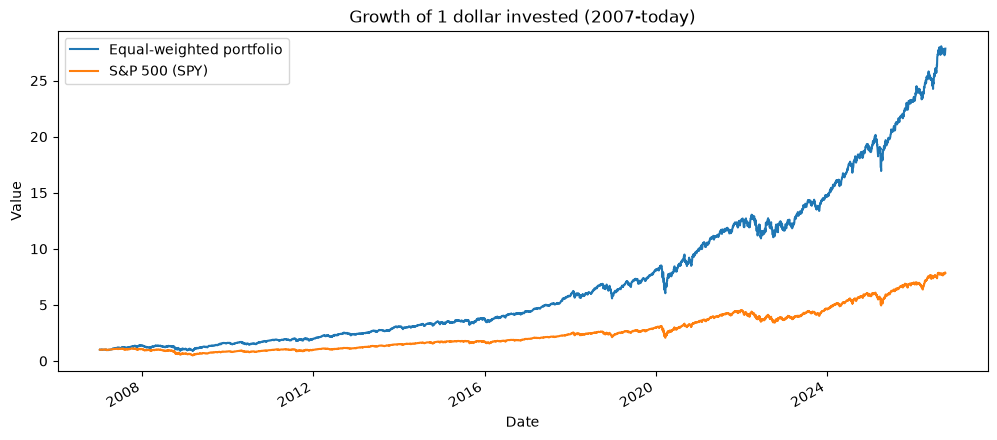

In [25]:
# Growth of 1 dollar: portfolio vs S&P 500 (cumulative product of 1 + daily return)
growth = pd.DataFrame({
    'Equal-weighted portfolio': (1 + port_ret).cumprod(),
    'S&P 500 (SPY)': (1 + market).cumprod(),
})
growth.plot(figsize=(12, 5), title='Growth of 1 dollar invested (2007-today)')
plt.ylabel('Value')
plt.show()

In [26]:
# Final value of 1 dollar invested in 2007
print(growth.iloc[-1].round(2))

Equal-weighted portfolio    27.85
S&P 500 (SPY)                7.85
Name: 2026-10-08 00:00:00, dtype: float64


## Key takeaways

- Volatility ranges from 17.7% (JNJ) to 37.6% (AMZN); defensive sectors are the least volatile.
- Higher return came with higher volatility for AAPL, but not for XOM (high volatility, low return).
- Correlations are positive but moderate (0.25 to 0.55), and rise during crises.
- Diversification reduces portfolio volatility by 31.9% compared with the average of the components.
-  1 dollar invested in 2007 in the equal-weighted portfolio grew to 27.85 dollars, versus 7.85 dollars for the S&P 500, with a lower volatility (18.60% vs 19.54%). This result should be read with caution: the 8 stocks were selected with hindsight (survivorship bias).
- In calm markets, stocks are weakly correlated. During crises, common shocks push correlations higher. Diversification reduces risk by ~50% at 0.12 correlation, but only ~10% at 0.79. Calm-period risk models underestimate crisis risk, making stress tests essential.

## 6. Drawdown

So far, volatility treats gains and losses equally and does not tell us how much an
investor would actually have lost. In this section, I measure the **drawdown**: how far
the portfolio is below its previous peak at each date. The **maximum drawdown** is the
worst peak-to-trough loss over the whole period.

In [27]:
# Value of 1 dollar invested, running maximum, and drawdown from that maximum
wealth = (1 + port_ret).cumprod()
peak = wealth.cummax()
drawdown = wealth / peak - 1
print(drawdown.tail())

Date
2026-10-02   -0.026632
2026-10-05   -0.024496
2026-10-06   -0.017453
2026-10-07   -0.013068
2026-10-08   -0.007505
dtype: float64


In [28]:
# Worst peak-to-trough loss and the date of the trough
max_dd = drawdown.min()
trough_date = drawdown.idxmin()
print(f'Maximum drawdown: {max_dd:.2%} on {trough_date.date()}')

Maximum drawdown: -36.42% on 2009-03-09


In [29]:
# Date of the peak that preceded the trough
peak_date = wealth.loc[:trough_date].idxmax()
print(f'Peak before the trough: {peak_date.date()}')
print(f'Fall lasted {(trough_date - peak_date).days} days')

Peak before the trough: 2007-12-26
Fall lasted 439 days


In [30]:
# When did the portfolio get back to its previous peak?
peak_value = wealth.loc[peak_date]
after_trough = wealth.loc[trough_date:]
recovered = after_trough[after_trough >= peak_value]

if len(recovered) > 0:
    recovery_date = recovered.index[0]
    print(f'Recovered on {recovery_date.date()}')
    print(f'Recovery lasted {(recovery_date - trough_date).days} days')
else:
    print('Not recovered yet')

Recovered on 2009-09-16
Recovery lasted 191 days


In [31]:
def compute_drawdown(r):
    # Drawdown series from a series (or table) of daily returns
    wealth = (1 + r).cumprod()
    return wealth / wealth.cummax() - 1

dd_port = compute_drawdown(port_ret)
dd_market = compute_drawdown(market)

print(f'Portfolio maximum drawdown: {dd_port.min():.2%} on {dd_port.idxmin().date()}')
print(f'S&P 500 maximum drawdown:   {dd_market.min():.2%} on {dd_market.idxmin().date()}')

Portfolio maximum drawdown: -36.42% on 2009-03-09
S&P 500 maximum drawdown:   -55.19% on 2009-03-09


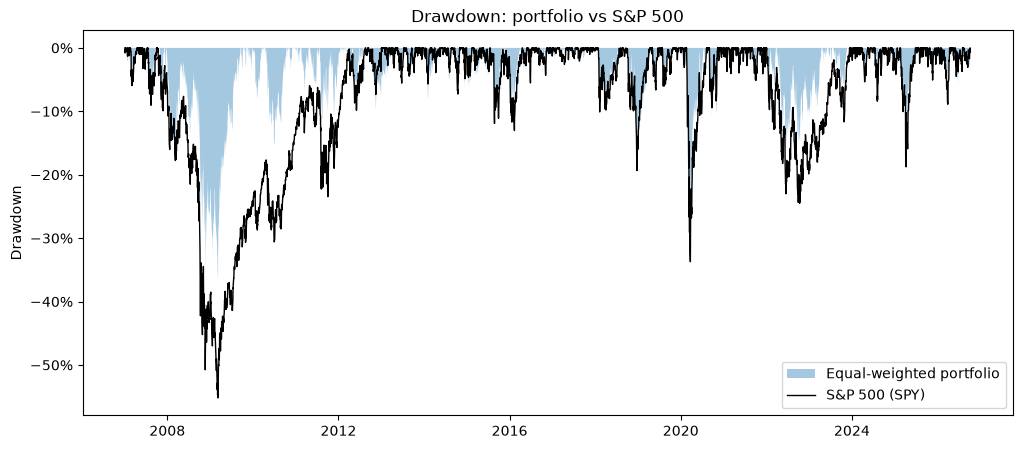

In [32]:
# Drawdown of the portfolio (filled) vs the S&P 500 (line)
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dd_port.index, dd_port, 0, alpha=0.4, label='Equal-weighted portfolio')
ax.plot(dd_market, color='black', linewidth=1, label='S&P 500 (SPY)')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Drawdown: portfolio vs S&P 500')
ax.set_ylabel('Drawdown')
ax.legend()
plt.show()

In [33]:
# Max drawdown of each individual stock
dd_stocks = stocks.apply(compute_drawdown)
print((dd_stocks.min() * 100).round(1).sort_values())

JPM    -68.1
AMZN   -65.3
XOM    -62.4
AAPL   -60.9
MSFT   -57.9
KO     -40.6
WMT    -36.4
JNJ    -34.4
dtype: float64


In [34]:
# Share of days where the portfolio is more than 10% below its peak
share = (dd_port < -0.10).mean()
print(f'Days with a drawdown worse than -10%: {share:.1%}')

Days with a drawdown worse than -10%: 8.8%


**Results:**
- Portfolio maximum drawdown: -36.42% on 2009-03-09, after a peak on 2007-12-26.
  The fall lasted 439 days and the recovery 191 days (recovered on 2009-09-16), so the
  portfolio spent about 21 months below its previous peak.
- S&P 500 maximum drawdown: -55.19% on the same date (2009-03-09).
- Individual stocks: maximum drawdowns range from -34.4% (JNJ) to -68.1% (JPM). Defensive
  stocks (JNJ, WMT, KO) fell by 34-41%, whereas JPM, AMZN, XOM, AAPL and MSFT fell by 58-68%.
- The portfolio spent 8.8% of the days (about 1 day out of 11) more than 10% below its peak.

**Interpretation:** a volatility of 18.6% looks moderate, but the worst loss was 36.42%, about twice as large. Volatility describes normal daily fluctuations, whereas the maximum drawdown shows what an investor would actually have lost in a crisis. Diversification also helps for drawdowns: the portfolio's worst loss is about the same as that of
the safest stocks, and much smaller than that of the others, since individual stocks do not reach their lowest point at the same time.

## 7. Beta, Sharpe ratio and Sortino ratio

Volatility and drawdown measure how large the risk is. Here I add two questions:
how much does the portfolio follow the market (**beta**), and is the risk taken
well rewarded (**Sharpe** and **Sortino** ratios)?

In [35]:
# Beta = covariance(portfolio, market) / variance(market)
beta_port = port_ret.cov(market) / market.var()
print(f'Portfolio beta: {beta_port:.2f}')

Portfolio beta: 0.88


In [36]:
# Beta is the slope of the line fitted through the cloud of points (market, portfolio)
slope, intercept = np.polyfit(market, port_ret, 1)
print(f'Slope (beta): {slope:.4f} | formula: {beta_port:.4f}')

Slope (beta): 0.8756 | formula: 0.8756


In [37]:
# Beta of each stock (lambda = a small function without a name, applied to each column)
betas = stocks.apply(lambda col: col.cov(market) / market.var())
print(betas.round(2).sort_values())

# The portfolio beta is the weighted average of the stock betas
print(f'Weighted average of betas: {(betas * weights).sum():.4f}')

JNJ     0.50
WMT     0.51
KO      0.54
XOM     0.87
MSFT    1.04
AAPL    1.06
AMZN    1.14
JPM     1.35
dtype: float64
Weighted average of betas: 0.8756


In [38]:
# R-squared = share of the portfolio variance explained by the market
r_squared = port_ret.corr(market) ** 2
print(f'R-squared: {r_squared:.1%}')
print(f'Market (systematic) risk share: {r_squared:.1%} | stock-specific share: {1 - r_squared:.1%}')

R-squared: 84.6%
Market (systematic) risk share: 84.6% | stock-specific share: 15.4%


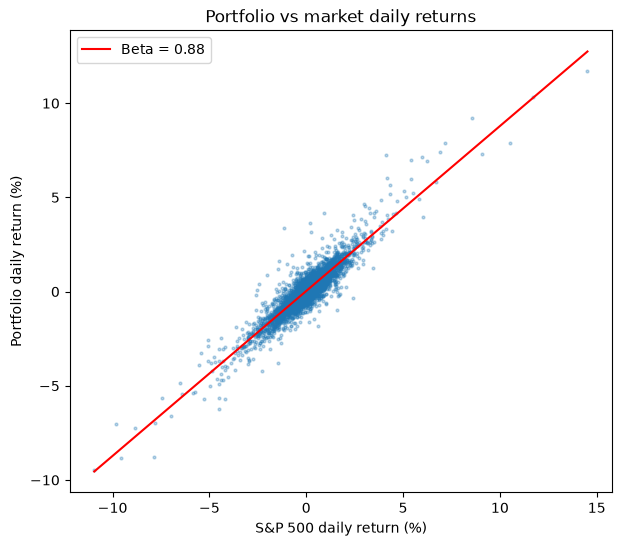

In [39]:
# Scatter plot of daily returns (in %) with the fitted line
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(market * 100, port_ret * 100, s=4, alpha=0.3)

x_line = np.array([market.min(), market.max()]) * 100
ax.plot(x_line, intercept * 100 + slope * x_line, color='red', label=f'Beta = {slope:.2f}')

ax.set_xlabel('S&P 500 daily return (%)')
ax.set_ylabel('Portfolio daily return (%)')
ax.set_title('Portfolio vs market daily returns')
ax.legend()
plt.show()

In [40]:
def risk_adjusted_stats(r, rf=RISK_FREE):
    # Annualized return, volatility, Sharpe and Sortino from a series of daily returns
    ann_return = r.mean() * TRADING_DAYS
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    rf_daily = rf / TRADING_DAYS
    downside_dev = np.sqrt((np.minimum(r - rf_daily, 0) ** 2).mean()) * np.sqrt(TRADING_DAYS)
    return pd.Series({
        'Annual return': ann_return,
        'Volatility': ann_vol,
        'Sharpe': (ann_return - rf) / ann_vol,
        'Downside deviation': downside_dev,
        'Sortino': (ann_return - rf) / downside_dev,
    })

In [41]:
# Apply the function to the 8 stocks, the portfolio and the S&P 500
all_series = pd.concat([stocks, port_ret.rename('Portfolio'), market.rename('S&P 500')], axis=1)
summary = all_series.apply(risk_adjusted_stats).T    # .T = transpose (one row per asset)

summary[['Annual return', 'Volatility', 'Downside deviation']] *= 100
print(summary.round(2).sort_values('Sharpe', ascending=False))

           Annual return  Volatility  Sharpe  Downside deviation  Sortino
AAPL               29.78       31.21    0.89               21.37     1.30
Portfolio          18.59       18.60    0.89               12.76     1.30
AMZN               31.70       37.64    0.79               24.06     1.23
MSFT               20.24       28.14    0.65               18.98     0.96
WMT                14.06       21.01    0.57               14.45     0.83
JNJ                11.32       17.72    0.53               12.25     0.76
S&P 500            12.35       19.54    0.53               13.89     0.75
KO                 11.30       18.70    0.50               13.00     0.72
JPM                19.09       36.96    0.46               24.49     0.70
XOM                11.25       26.98    0.34               18.67     0.50


**Results:**
- Portfolio beta: 0.88. When the S&P 500 moves by 10%, the portfolio moves by about 8.8%
  on average. Betas of individual stocks range from 0.50 (JNJ) to 1.35 (JPM). The portfolio beta equals the weighted average of the stock betas (0.8756).
- R-squared: 84.6%, so 84.6% of the portfolio variance comes from market risk (not
  diversifiable) and 15.4% from stock-specific risk.
- Sharpe ratio: 0.89 for the portfolio vs 0.53 for the S&P 500. Sortino ratio: 1.30 vs 0.75.
- Best Sharpe ratio among the stocks: AAPL (0.89). Worst: XOM (0.34).

**Interpretation:**
- Defensive stocks (JNJ, WMT, KO) have betas around 0.5, JPM has the highest beta (1.35).
  This is consistent with the maximum drawdowns observed earlier
- Of the portfolio volatility of 18.6%, about 17.1% comes from the market (beta x market
  volatility) and about 7.3% from stock-specific risk. Diversifying across 8 stocks removes most of the specific risk, but nothing can remove market risk within an all-equity portfolio.
- The equal-weighted portfolio matches the best stock (AAPL) in Sharpe ratio with 40% less
  volatility (18.6% vs 31.2%): its return is the average of the stock returns, but its risk is lower than the average risk, thanks to diversification.
- The Sortino ratio is higher than the Sharpe ratio for every asset because the downside deviation is about 0.7 times the volatility. The ranking is almost identical, which suggests that returns are fairly symmetric.

**Caution:** beta is not stable over time (it rises in crises) and depends on the benchmark. Here the S&P 500 contains most of these stocks, which mechanically increases the R-squared.The Sharpe ratio assumes that volatility captures all the risk and uses a constant risk-free rate of 2%. All ratios are based on past data and inflated by survivorship bias.